# FedX-PALM: Centralized YOLOv11 Training (Baseline)

**Master's Thesis - Rachma Dianty (201012420007)** · Telkom University, 2026

---

## Tujuan
Notebook ini melatih YOLOv11 secara **centralized** (semua data digabung di satu tempat) menggunakan dataset Roboflow Anda. Ini adalah **baseline pembanding** untuk eksperimen Federated Learning di tahap berikutnya (Tabel 4.4 tesis: target centralized mAP@0.5 ≈ 0.921).

## Tahapan
1. Setup environment (Ultralytics + Roboflow)
2. Verifikasi class names dari Roboflow (CRITICAL — pastikan urutan sesuai tesis)
3. Download dataset (6 kelas)
4. Train YOLOv11 Nano (100 epochs, batch 16, img 640)
5. Evaluasi mAP@0.5 / Precision / Recall / F1
6. Simpan checkpoint `.pt` ke Google Drive (untuk dipakai sebagai $w_0$ di FL nanti)

## Spesifikasi (Tabel 3.5 tesis)
| Param | Nilai |
|-------|-------|
| Model | YOLOv11 Nano (`yolo11n.pt`) |
| Classes | 6 |
| Input | 640×640 |
| Optimizer | AdamW |
| Loss | CIoU |
| LR | 0.01 |
| Batch | 16 |
| Epochs | 100 |
| GPU | NVIDIA Tesla T4 (Colab Pro) |

## 1. Setup Environment

In [1]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 135.9 MB/s eta 0:00:00


In [2]:
import torch, ultralytics, roboflow
from ultralytics import YOLO

print(f'PyTorch     : {torch.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Ultralytics : {ultralytics.__version__}')
print(f'Roboflow    : {roboflow.__version__}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch     : 2.10.0+cu128
CUDA        : True
GPU         : Tesla T4
VRAM        : 15.6 GB
Ultralytics : 8.4.51
Roboflow    : 1.3.8


## 2. Verifikasi Class Names dari Roboflow

**PENTING:** Cek nama & urutan kelas. Dataset Roboflow Anda pakai urutan alfabetis:

| Idx | Kelas (Roboflow) |
|-----|------------------|
| 0 | Abnormal |
| 1 | Empty Bunch |
| 2 | Overripe |
| 3 | Ripe |
| 4 | Underripe |
| 5 | Unripe |

Narasi tesis Bab 2.1.2 & Tabel 3.3/4.7/4.8 perlu disesuaikan ke urutan ini (lihat catatan revisi).

In [3]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = 'Ej0bSMpeSri3ky0IYkOU'

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace('dydy-worker').project('palm-fruit-ripeness-detection-f6sac-ccb2z')

print(f'Project Name : {project.name}')
print(f'Type         : {project.type}')
print(f'Classes      : {project.classes}')
print()

# Roboflow uses alphabetical class order (decided: thesis follows this)
EXPECTED_ROBOFLOW = ['Abnormal', 'Empty Bunch', 'Overripe', 'Ripe', 'Underripe', 'Unripe']
roboflow_classes = list(project.classes.keys()) if isinstance(project.classes, dict) else list(project.classes)

print(f'Expected (Roboflow alphabetical): {EXPECTED_ROBOFLOW}')
print(f'Actual (from Roboflow API)     : {roboflow_classes}')
print()

norm_expected = [c.lower().replace('_', ' ').strip() for c in EXPECTED_ROBOFLOW]
norm_actual   = [c.lower().replace('_', ' ').strip() for c in roboflow_classes]

if norm_actual == norm_expected:
    print('✅ MATCH: urutan kelas sesuai. Lanjut ke download dataset.')
elif sorted(norm_actual) == sorted(norm_expected):
    print('⚠️  Nama kelas sama, urutan beda. Lanjut, tapi catat urutan aktual untuk update kode/tesis.')
else:
    print('❌ CLASS MISMATCH: ada nama kelas yang berbeda — cek manual!')
    print('    Diff:', set(EXPECTED_ROBOFLOW) ^ set(roboflow_classes))

loading Roboflow workspace...
loading Roboflow project...
Project Name : Palm Fruit Ripeness Detection
Type         : object-detection
Classes      : {'Overripe': 2641, 'Empty Bunch': 857, 'Underripe': 2575, 'Ripe': 2973, 'Unripe': 2913, 'Abnormal': 2599}

Expected (Roboflow alphabetical): ['Abnormal', 'Empty Bunch', 'Overripe', 'Ripe', 'Underripe', 'Unripe']
Actual (from Roboflow API)     : ['Overripe', 'Empty Bunch', 'Underripe', 'Ripe', 'Unripe', 'Abnormal']

⚠️  Nama kelas sama, urutan beda. Lanjut, tapi catat urutan aktual untuk update kode/tesis.


## 3. Download Dataset

In [4]:
import os
os.makedirs('/content/data', exist_ok=True)

version = project.version(2)
dataset = version.download('yolov11', location='/content/data/palm_v2')
print(f'\nDataset location: {dataset.location}')
print(f'data.yaml       : {dataset.location}/data.yaml')


Extracting Dataset Version Zip to /content/data/palm_v2 in yolov11:: 100%|██████████| 21640/21640 [00:04<00:00, 5377.38it/s]


Dataset location: /content/data/palm_v2
data.yaml       : /content/data/palm_v2/data.yaml


In [5]:
# Inspect data.yaml from Roboflow
with open(f'{dataset.location}/data.yaml') as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 6
names: ['Abnormal', 'Empty Bunch', 'Overripe', 'Ripe', 'Underripe', 'Unripe']

roboflow:
  workspace: dydy-worker
  project: palm-fruit-ripeness-detection-f6sac-ccb2z
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/dydy-worker/palm-fruit-ripeness-detection-f6sac-ccb2z/dataset/2


In [6]:
# Count images per split & per class
from pathlib import Path
from collections import Counter

root = Path(dataset.location)
for split in ['train', 'valid', 'test']:
    img_dir = root / split / 'images'
    lbl_dir = root / split / 'labels'
    if not img_dir.exists():
        continue
    n_img = len(list(img_dir.glob('*.jpg'))) + len(list(img_dir.glob('*.png')))
    cls_counter = Counter()
    for lbl in lbl_dir.glob('*.txt'):
        with open(lbl) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls_counter[int(parts[0])] += 1
    print(f'\n{split.upper():6s} | images={n_img:5d} | annotations per class: {dict(sorted(cls_counter.items()))}')


TRAIN  | images= 9982 | annotations per class: {0: 6387, 1: 2033, 2: 6241, 3: 6854, 4: 6087, 5: 7109}

VALID  | images=  416 | annotations per class: {0: 219, 1: 92, 2: 293, 3: 347, 4: 289, 5: 251}

TEST   | images=  416 | annotations per class: {0: 251, 1: 87, 2: 266, 3: 341, 4: 257, 5: 292}


## 4. Train YOLOv11 Nano (Centralized Baseline)

Estimasi waktu di Tesla T4: ~5–7 menit per epoch × 100 epoch ≈ 8–12 jam.
Untuk smoke test pakai `epochs=10` dulu, baru `epochs=100` untuk run final.

In [9]:
# ====== TRAINING CONFIG (sinkron dengan Tabel 3.5 tesis) ======
MODEL_VARIANT  = 'yolo11n.pt'   # Nano (smallest, fastest)
IMG_SIZE       = 640
BATCH_SIZE     = 16
EPOCHS         = 50            # ganti ke 10 untuk smoke test
OPTIMIZER      = 'SGD'
LR0            = 0.01
PATIENCE       = 20
PROJECT_DIR    = '/content/runs/centralized'
RUN_NAME       = 'palm_yolov11n_100ep'

DATA_YAML = f'{dataset.location}/data.yaml'
print(f'Training config:')
print(f'  model     = {MODEL_VARIANT}')
print(f'  epochs    = {EPOCHS}')
print(f'  batch     = {BATCH_SIZE}')
print(f'  img       = {IMG_SIZE}')
print(f'  optimizer = {OPTIMIZER}, lr0={LR0}')
print(f'  data.yaml = {DATA_YAML}')

Training config:
  model     = yolo11n.pt
  epochs    = 50
  batch     = 16
  img       = 640
  optimizer = SGD, lr0=0.01
  data.yaml = /content/data/palm_v2/data.yaml


In [10]:
model = YOLO(MODEL_VARIANT)

results = model.train(
    data       = DATA_YAML,
    epochs     = EPOCHS,
    imgsz      = IMG_SIZE,
    batch      = BATCH_SIZE,
    optimizer  = OPTIMIZER,
    lr0        = LR0,
    patience   = PATIENCE,
    project    = PROJECT_DIR,
    name       = RUN_NAME,
    exist_ok   = True,
    plots      = True,
    save       = True,
    device     = 0,
)
print('\n✅ Training selesai.')
print(f'Best weights: {PROJECT_DIR}/{RUN_NAME}/weights/best.pt')

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/palm_v2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=palm_yolov11n_100ep, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, pa

In [20]:
import shutil
shutil.make_archive('/content/centralized_results', 'zip',
                    '/content/runs/centralized/palm_yolov11n_100ep')

from google.colab import files
files.download('/content/centralized_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree('/content/runs/centralized/palm_yolov11n_100ep',
                '/content/drive/MyDrive/fedx-palm/centralized_baseline',
                dirs_exist_ok=True)
print('Saved to Drive ✓')

Mounted at /content/drive
Saved to Drive ✓


## 5. Evaluasi Final pada Test Set

Metrik di sini akan jadi **angka real untuk Tabel 4.4 (baseline centralized)** di tesis Anda.

In [11]:
best_weights = f'{PROJECT_DIR}/{RUN_NAME}/weights/best.pt'
best_model = YOLO(best_weights)

metrics = best_model.val(
    data  = DATA_YAML,
    imgsz = IMG_SIZE,
    batch = BATCH_SIZE,
    split = 'val',
    project = PROJECT_DIR,
    name    = f'{RUN_NAME}_eval',
    exist_ok = True,
)

print('\n=== Centralized Baseline Metrics ===')
print(f'mAP@0.5      : {metrics.box.map50:.4f}')
print(f'mAP@0.5:0.95 : {metrics.box.map:.4f}')
print(f'Precision    : {metrics.box.mp:.4f}')
print(f'Recall       : {metrics.box.mr:.4f}')

# Per-class
print('\n--- Per-class mAP@0.5 ---')
for i, name in enumerate(best_model.names.values()):
    if i < len(metrics.box.maps):
        print(f'  {i} {name:15s}: {metrics.box.maps[i]:.4f}')

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2262.7±722.2 MB/s, size: 72.8 KB)
val: Scanning /content/data/palm_v2/valid/labels.cache... 416 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 416/416 134.2Mit/s 0.0s
val: /content/data/palm_v2/valid/images/framesawit27-11-_png_jpg.rf.c3fe7e65e978cece9bb83eebe940ecdf.jpg: 1 duplicate labels removed
val: /content/data/palm_v2/valid/images/framesawit39-3-_png_jpg.rf.5a47be515878d0789385f2cff89f4264.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 4.6it/s 5.6s
                   all        416       1489      0.995      0.994      0.995      0.901
              Abnormal        114        219      0.994      0.991      0.993      0.856
           Empty Bunch         52         

In [ ]:
# Compute F1 (harmonic mean of precision & recall)
P, R = metrics.box.mp, metrics.box.mr
F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0
print(f'F1-Score     : {F1:.4f}')

# Save summary to JSON for the thesis report
import json, datetime
summary = {
    'experiment'  : 'centralized_baseline',
    'timestamp'   : datetime.datetime.utcnow().isoformat(),
    'model'       : MODEL_VARIANT,
    'epochs'      : EPOCHS,
    'batch'       : BATCH_SIZE,
    'img_size'    : IMG_SIZE,
    'optimizer'   : OPTIMIZER,
    'lr0'         : LR0,
    'mAP_50'      : float(metrics.box.map50),
    'mAP_50_95'   : float(metrics.box.map),
    'precision'   : float(P),
    'recall'      : float(R),
    'f1'          : float(F1),
    'per_class_mAP50': {name: float(metrics.box.maps[i]) for i, name in enumerate(best_model.names.values()) if i < len(metrics.box.maps)},
}
with open(f'{PROJECT_DIR}/{RUN_NAME}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

In [14]:
# Compute F1 (harmonic mean of precision & recall)
P, R = metrics.box.mp, metrics.box.mr
F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0

# Build per-class table.
# IMPORTANT: in Ultralytics box metrics,
#   - metrics.box.ap50  -> per-class mAP@0.5      (the "mAP50" everyone quotes)
#   - metrics.box.ap    -> per-class mAP@0.5:0.95 (the "mAP50-95")
#   - metrics.box.maps  -> per-class mAP@0.5:0.95 (alias of .ap, NOT mAP@0.5)
# The earlier "Per-class mAP@0.5" label used .maps and was therefore showing
# mAP@0.5:0.95 values. The block below uses the correct fields.
import pandas as pd, json, datetime

names_dict = best_model.names  # {0: 'Abnormal', 1: 'Empty Bunch', ...}
class_names = [names_dict[i] for i in sorted(names_dict)]
ap50  = metrics.box.ap50.tolist() if hasattr(metrics.box, 'ap50') else metrics.box.maps.tolist()
ap5095 = metrics.box.ap.tolist()   if hasattr(metrics.box, 'ap')   else metrics.box.maps.tolist()
p_cls = metrics.box.p.tolist()     if hasattr(metrics.box, 'p')    else [None] * len(class_names)
r_cls = metrics.box.r.tolist()     if hasattr(metrics.box, 'r')    else [None] * len(class_names)

per_class = pd.DataFrame({
    'class_id':    list(range(len(class_names))),
    'class_name':  class_names,
    'precision':   p_cls,
    'recall':      r_cls,
    'mAP_50':      ap50,
    'mAP_50_95':   ap5095,
})

print(f'F1-Score     : {F1:.4f}\n')
print('--- Per-class metrics ---')
print(per_class.to_string(index=False))

# Save summary to JSON + CSV
summary = {
    'experiment':   'centralized_baseline',
    'timestamp':    datetime.datetime.utcnow().isoformat(),
    'model':        MODEL_VARIANT,
    'epochs':       EPOCHS,
    'batch':        BATCH_SIZE,
    'img_size':     IMG_SIZE,
    'optimizer':    OPTIMIZER,
    'lr0':          LR0,
    'global': {
        'mAP_50':     float(metrics.box.map50),
        'mAP_50_95':  float(metrics.box.map),
        'precision':  float(P),
        'recall':     float(R),
        'f1':         float(F1),
    },
    'per_class': per_class.to_dict(orient='records'),
}

out_dir = f'{PROJECT_DIR}/{RUN_NAME}'
with open(f'{out_dir}/metrics_global.json', 'w') as f:
    json.dump(summary['global'], f, indent=2)
with open(f'{out_dir}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
per_class.to_csv(f'{out_dir}/metrics_per_class.csv', index=False)

print(f'\n✓ Saved metrics_global.json, summary.json, metrics_per_class.csv to {out_dir}')

F1-Score     : 0.9948

--- Per-class metrics ---
 class_id  class_name  precision   recall   mAP_50  mAP_50_95
        0    Abnormal   0.994351 0.990868 0.992569   0.856043
        1 Empty Bunch   0.999307 1.000000 0.995000   0.865598
        2    Overripe   0.987078 0.993151 0.994758   0.894439
        3        Ripe   1.000000 0.986925 0.994971   0.908740
        4   Underripe   0.995732 1.000000 0.994966   0.933001
        5      Unripe   0.994118 0.996016 0.995000   0.950179

✓ Saved metrics_global.json, summary.json, metrics_per_class.csv to /content/runs/centralized/palm_yolov11n_100ep


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


In [21]:
import shutil, json, pandas as pd
from pathlib import Path

src_train = Path(f'{PROJECT_DIR}/{RUN_NAME}')
src_eval  = Path(f'{PROJECT_DIR}/{RUN_NAME}_eval')
drive_dir = Path('/content/drive/MyDrive/fedx-palm/centralized_baseline')
drive_dir.mkdir(parents=True, exist_ok=True)
(drive_dir / 'eval_plots').mkdir(exist_ok=True)

# 1) Re-generate metrics_global.json + metrics_per_class.csv from existing summary.json
sj = json.load(open(src_train / 'summary.json'))
# Cell 15 lama format: top-level fields directly. Cell 15 baru: nested under 'global' + 'per_class'.
if 'global' in sj:
    global_metrics = sj['global']
    per_class      = pd.DataFrame(sj['per_class'])
else:
    global_metrics = {
        'mAP_50':    sj['mAP_50'],
        'mAP_50_95': sj['mAP_50_95'],
        'precision': sj['precision'],
        'recall':    sj['recall'],
        'f1':        sj['f1'],
    }
    # Build per_class from val result re-run
    from ultralytics import YOLO
    m = YOLO(str(src_train / 'weights/best.pt'))
    r = m.val(data=DATA_YAML, imgsz=IMG_SIZE, batch=BATCH_SIZE, verbose=False)
    names = [m.names[i] for i in sorted(m.names)]
    per_class = pd.DataFrame({
        'class_id':   list(range(len(names))),
        'class_name': names,
        'precision':  r.box.p.tolist(),
        'recall':     r.box.r.tolist(),
        'mAP_50':     r.box.ap50.tolist(),
        'mAP_50_95':  r.box.ap.tolist(),
    })

with open(src_train / 'metrics_global.json', 'w') as f:
    json.dump(global_metrics, f, indent=2)
per_class.to_csv(src_train / 'metrics_per_class.csv', index=False)

# 2) Copy missing files to Drive
for fname in ['metrics_global.json', 'metrics_per_class.csv', 'results.png']:
    src = src_train / fname
    if src.exists():
        shutil.copy2(src, drive_dir / fname)
        print(f'✓ {drive_dir / fname}')

for fname in ['BoxPR_curve.png', 'BoxF1_curve.png', 'BoxP_curve.png', 'BoxR_curve.png']:
    src = src_eval / fname
    if src.exists():
        shutil.copy2(src, drive_dir / 'eval_plots' / fname)
        print(f'✓ eval_plots/{fname}')

print('\nSelesai. Isi folder Drive:')
for f in sorted(drive_dir.rglob('*')):
    if f.is_file():
        print(f'  {f.relative_to(drive_dir)}  ({f.stat().st_size // 1024} KB)')

✓ /content/drive/MyDrive/fedx-palm/centralized_baseline/metrics_global.json
✓ /content/drive/MyDrive/fedx-palm/centralized_baseline/metrics_per_class.csv
✓ /content/drive/MyDrive/fedx-palm/centralized_baseline/results.png
✓ eval_plots/BoxPR_curve.png
✓ eval_plots/BoxF1_curve.png
✓ eval_plots/BoxP_curve.png
✓ eval_plots/BoxR_curve.png

Selesai. Isi folder Drive:
  BoxF1_curve.png  (156 KB)
  BoxPR_curve.png  (112 KB)
  BoxP_curve.png  (107 KB)
  BoxR_curve.png  (156 KB)
  args.yaml  (1 KB)
  best.pt  (5345 KB)
  confusion_matrix.png  (158 KB)
  confusion_matrix_normalized.png  (165 KB)
  eval_plots/BoxF1_curve.png  (156 KB)
  eval_plots/BoxPR_curve.png  (113 KB)
  eval_plots/BoxP_curve.png  (106 KB)
  eval_plots/BoxR_curve.png  (157 KB)
  eval_plots/confusion_matrix.png  (158 KB)
  eval_plots/confusion_matrix_normalized.png  (165 KB)
  labels.jpg  (160 KB)
  last.pt  (5345 KB)
  metrics_global.json  (0 KB)
  metrics_per_class.csv  (0 KB)
  results.csv  (5 KB)
  results.png  (273 KB)
  s

## 6. Confusion Matrix & Sample Predictions


confusion_matrix.png:


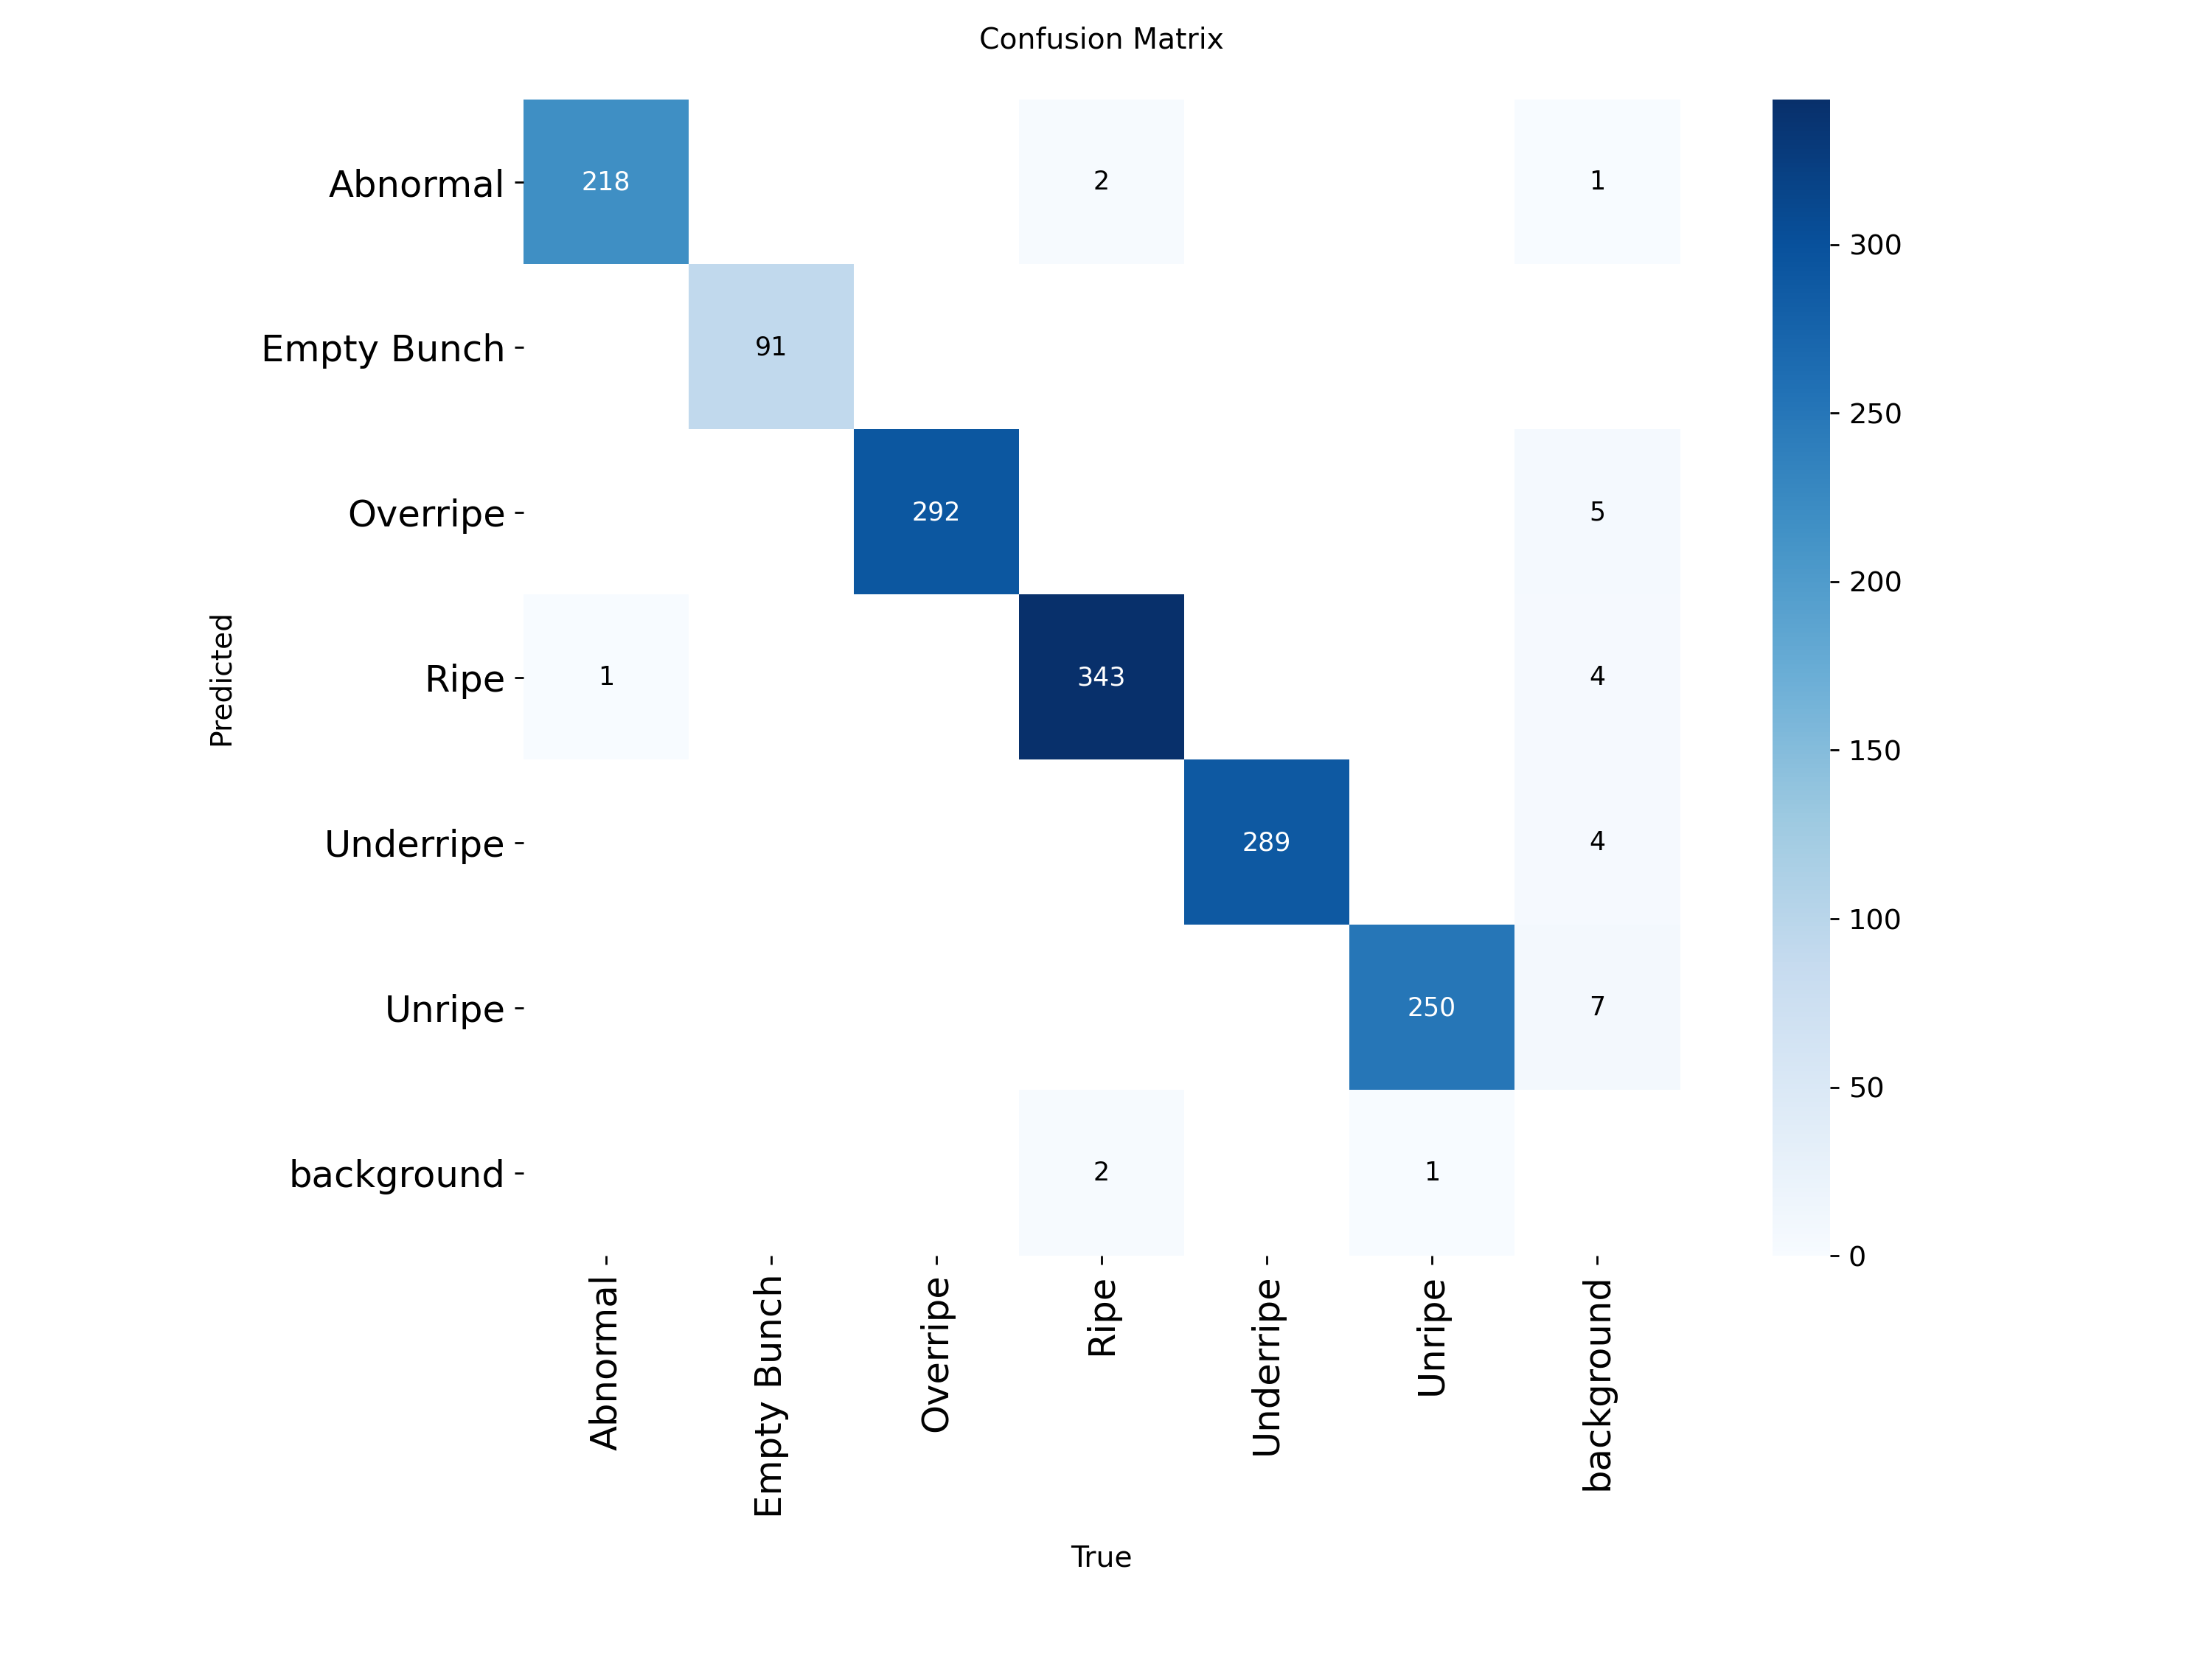


confusion_matrix_normalized.png:


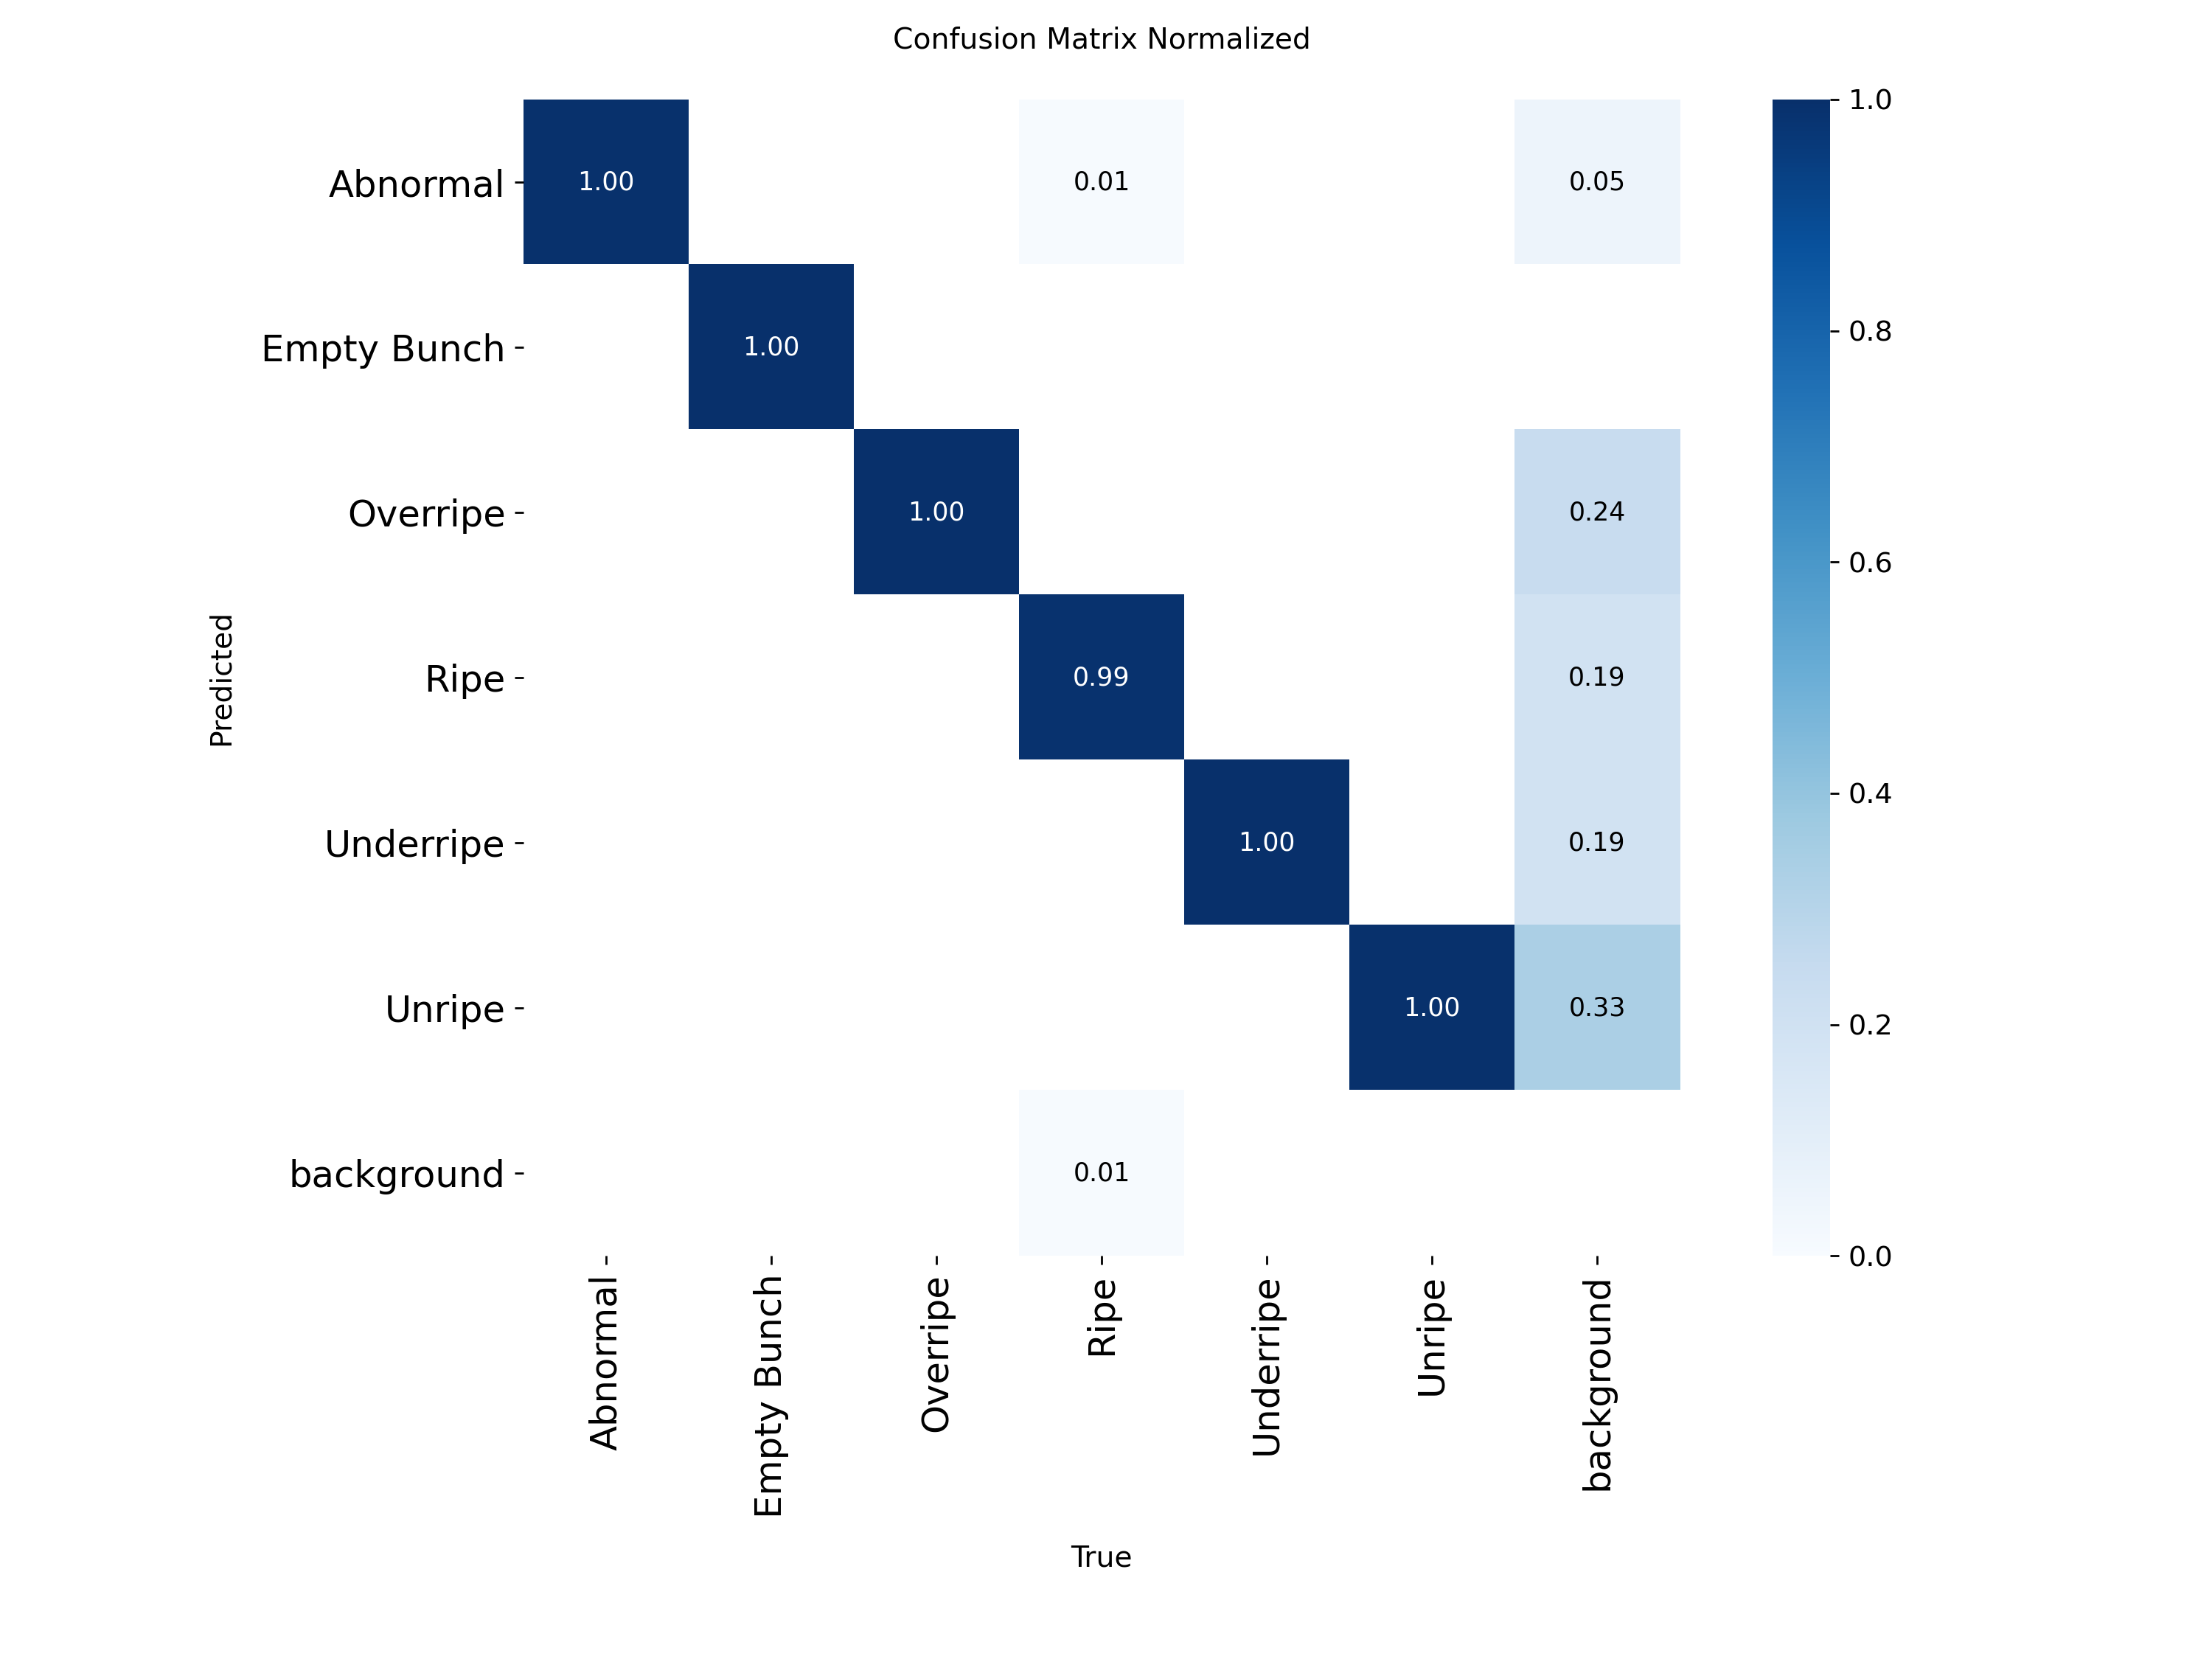


BoxPR_curve.png:


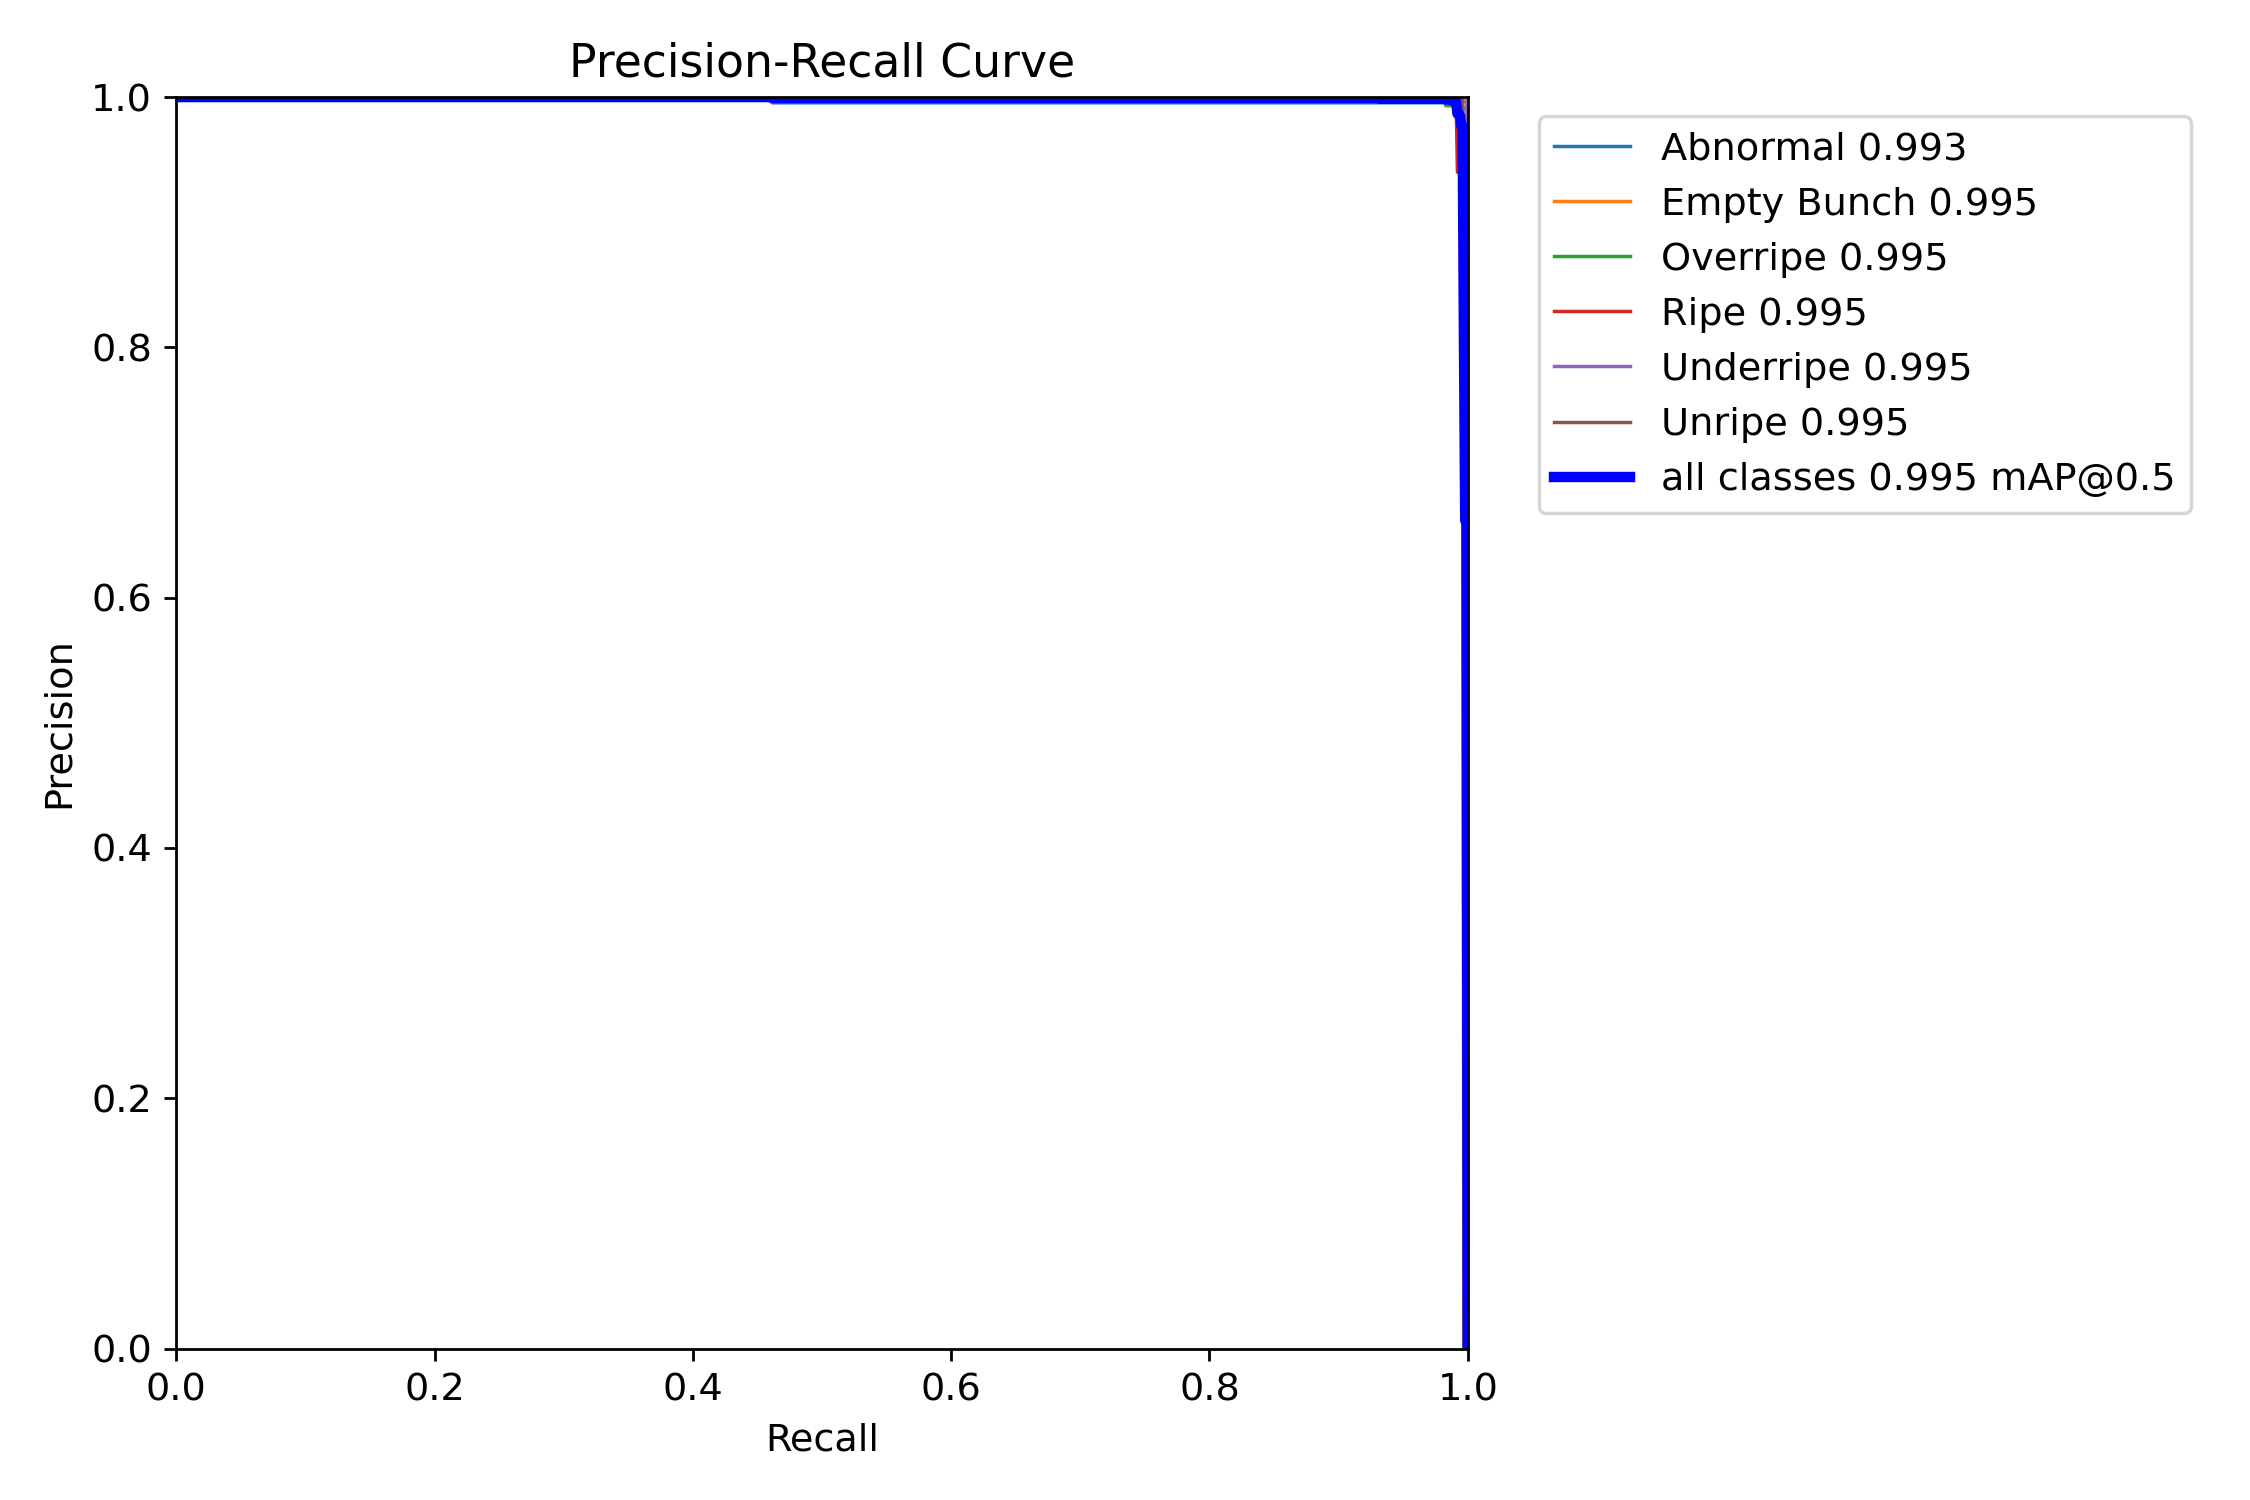


BoxF1_curve.png:


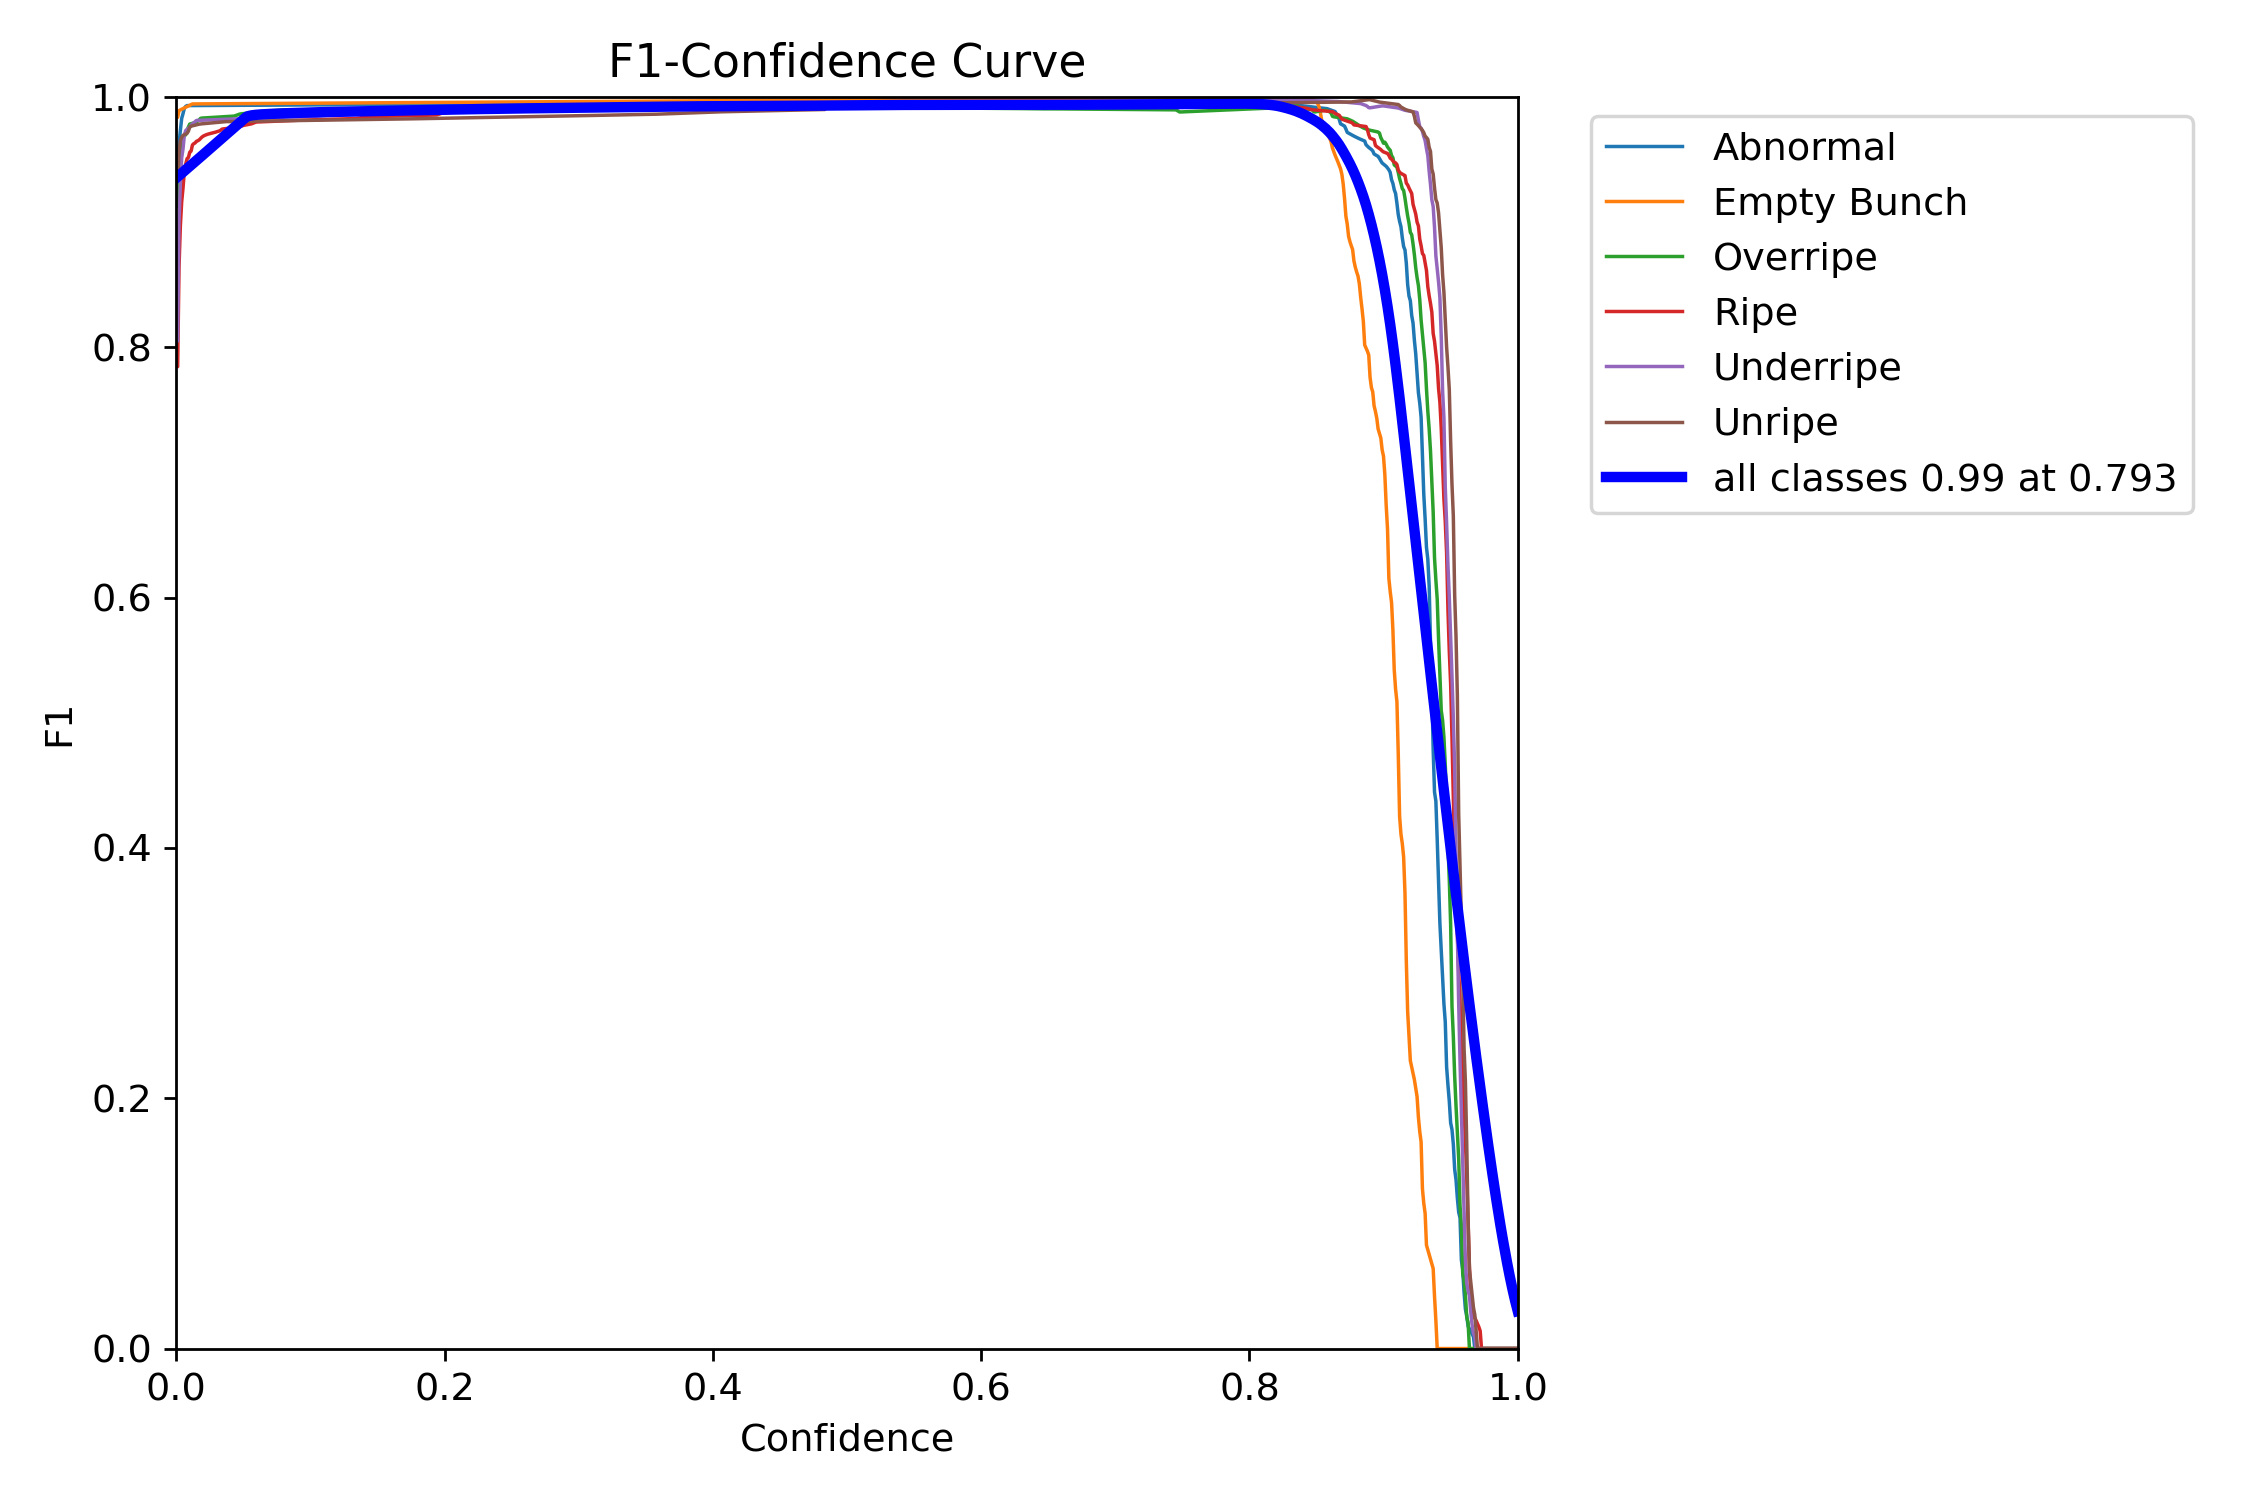


BoxP_curve.png:


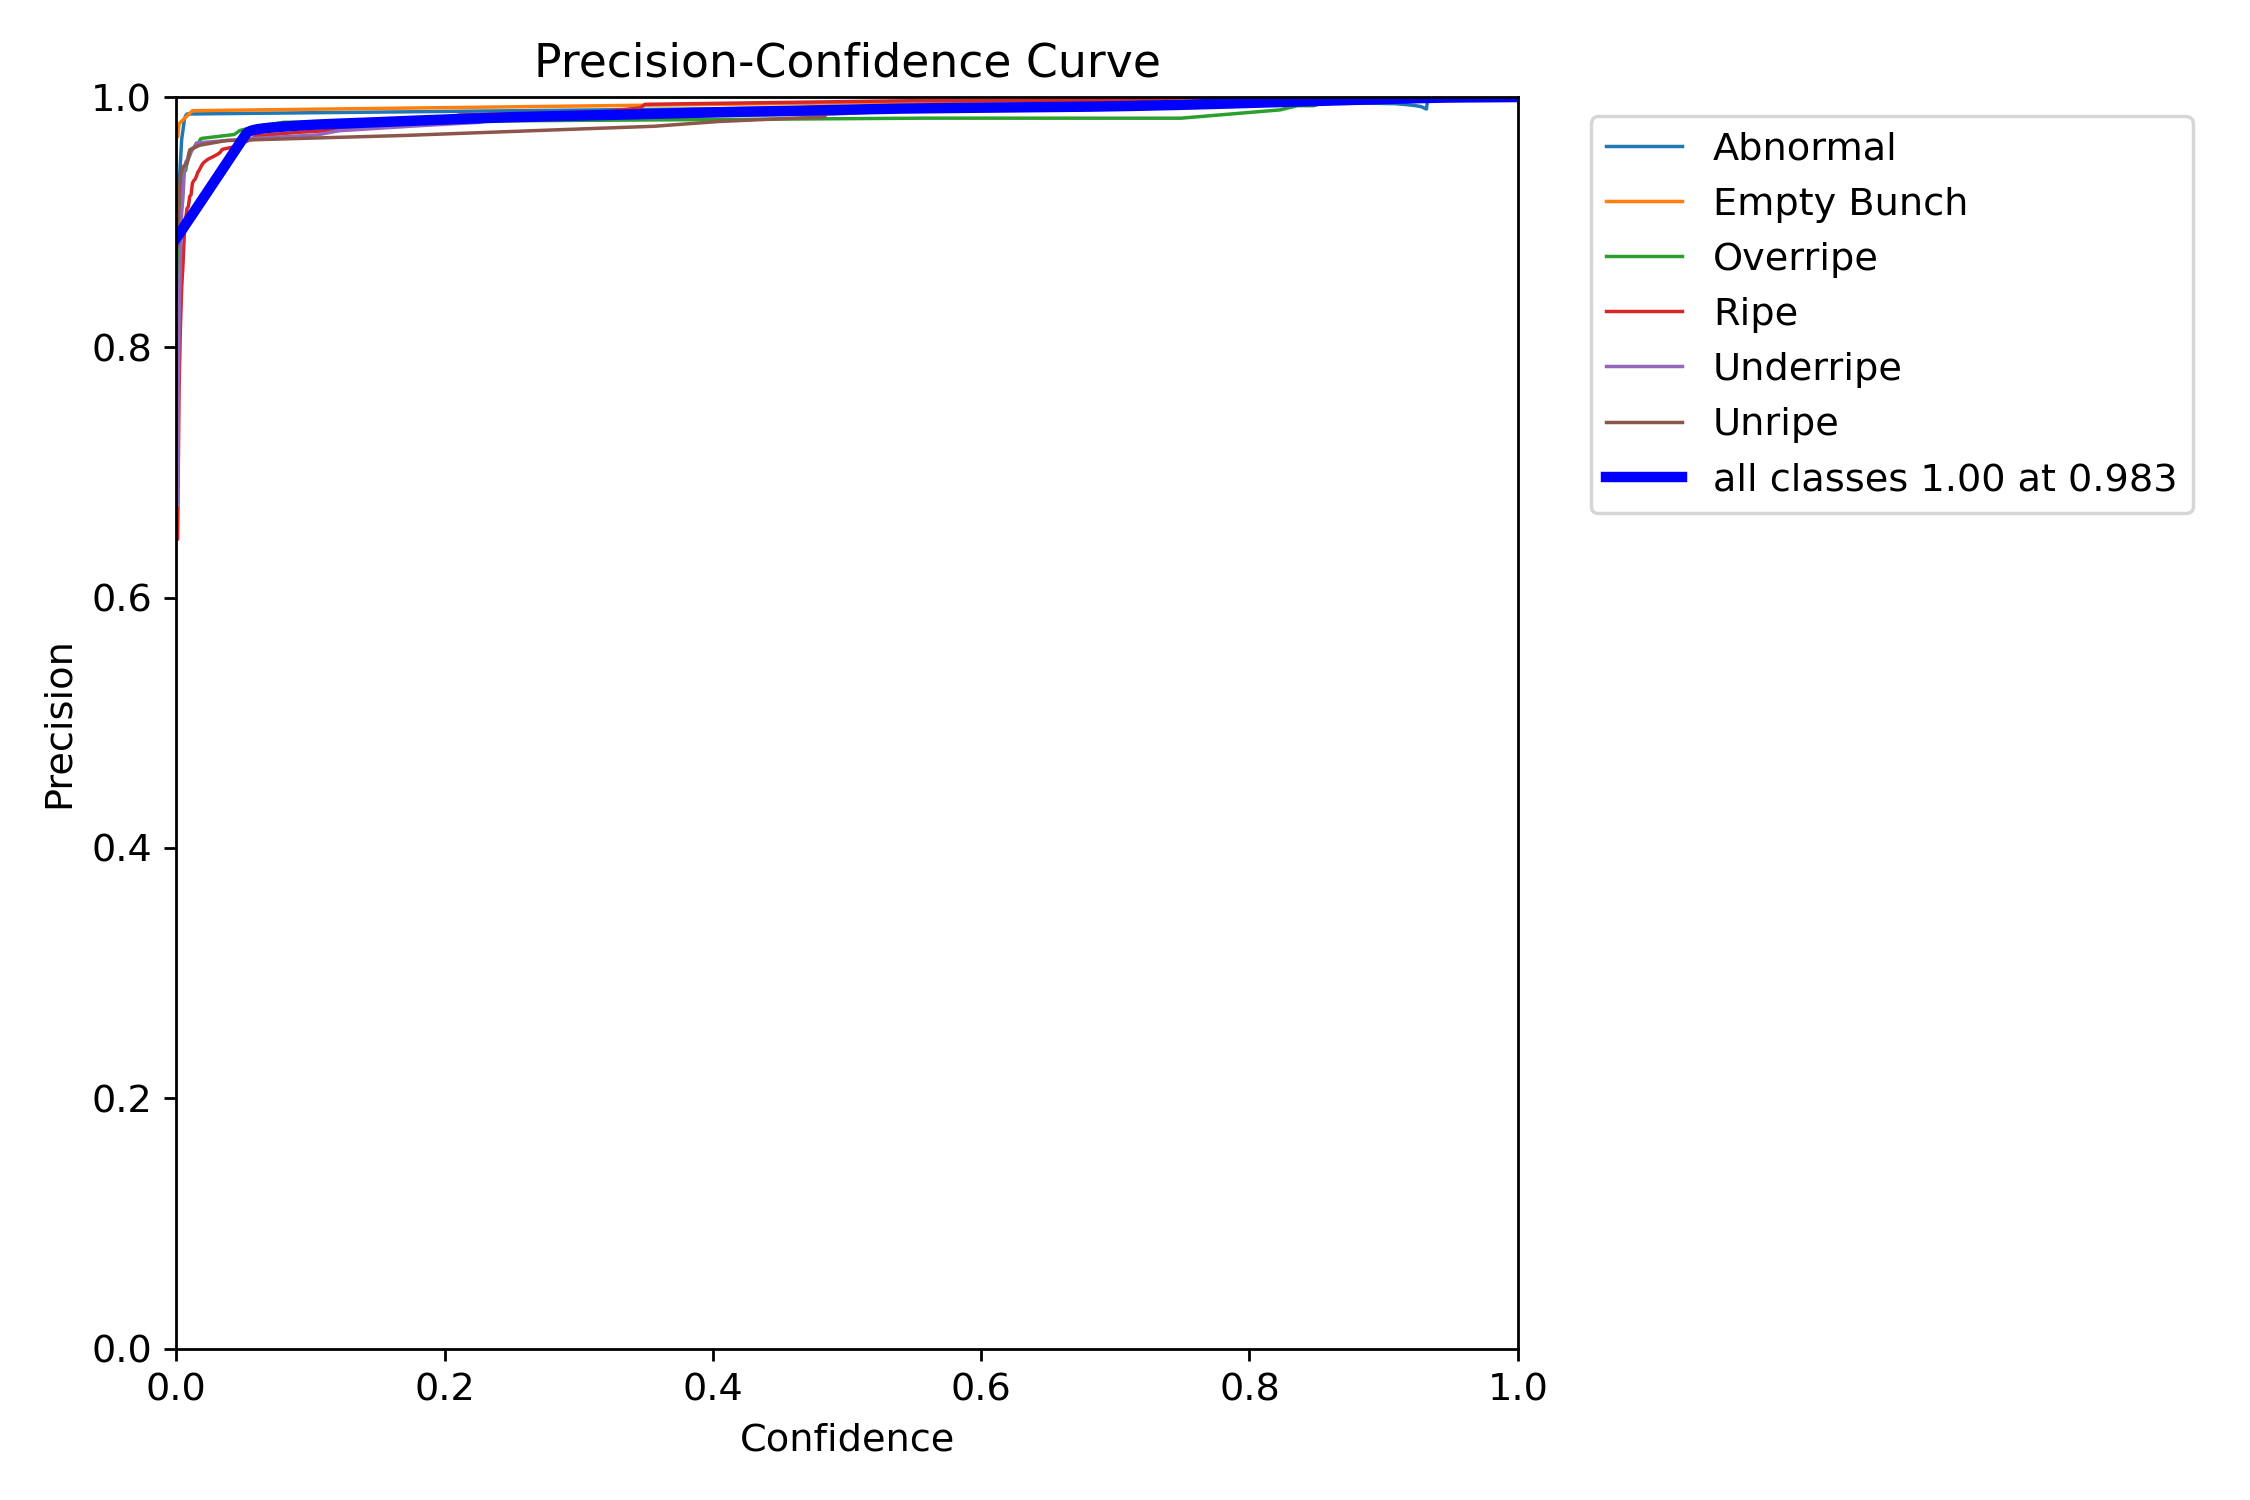


BoxR_curve.png:


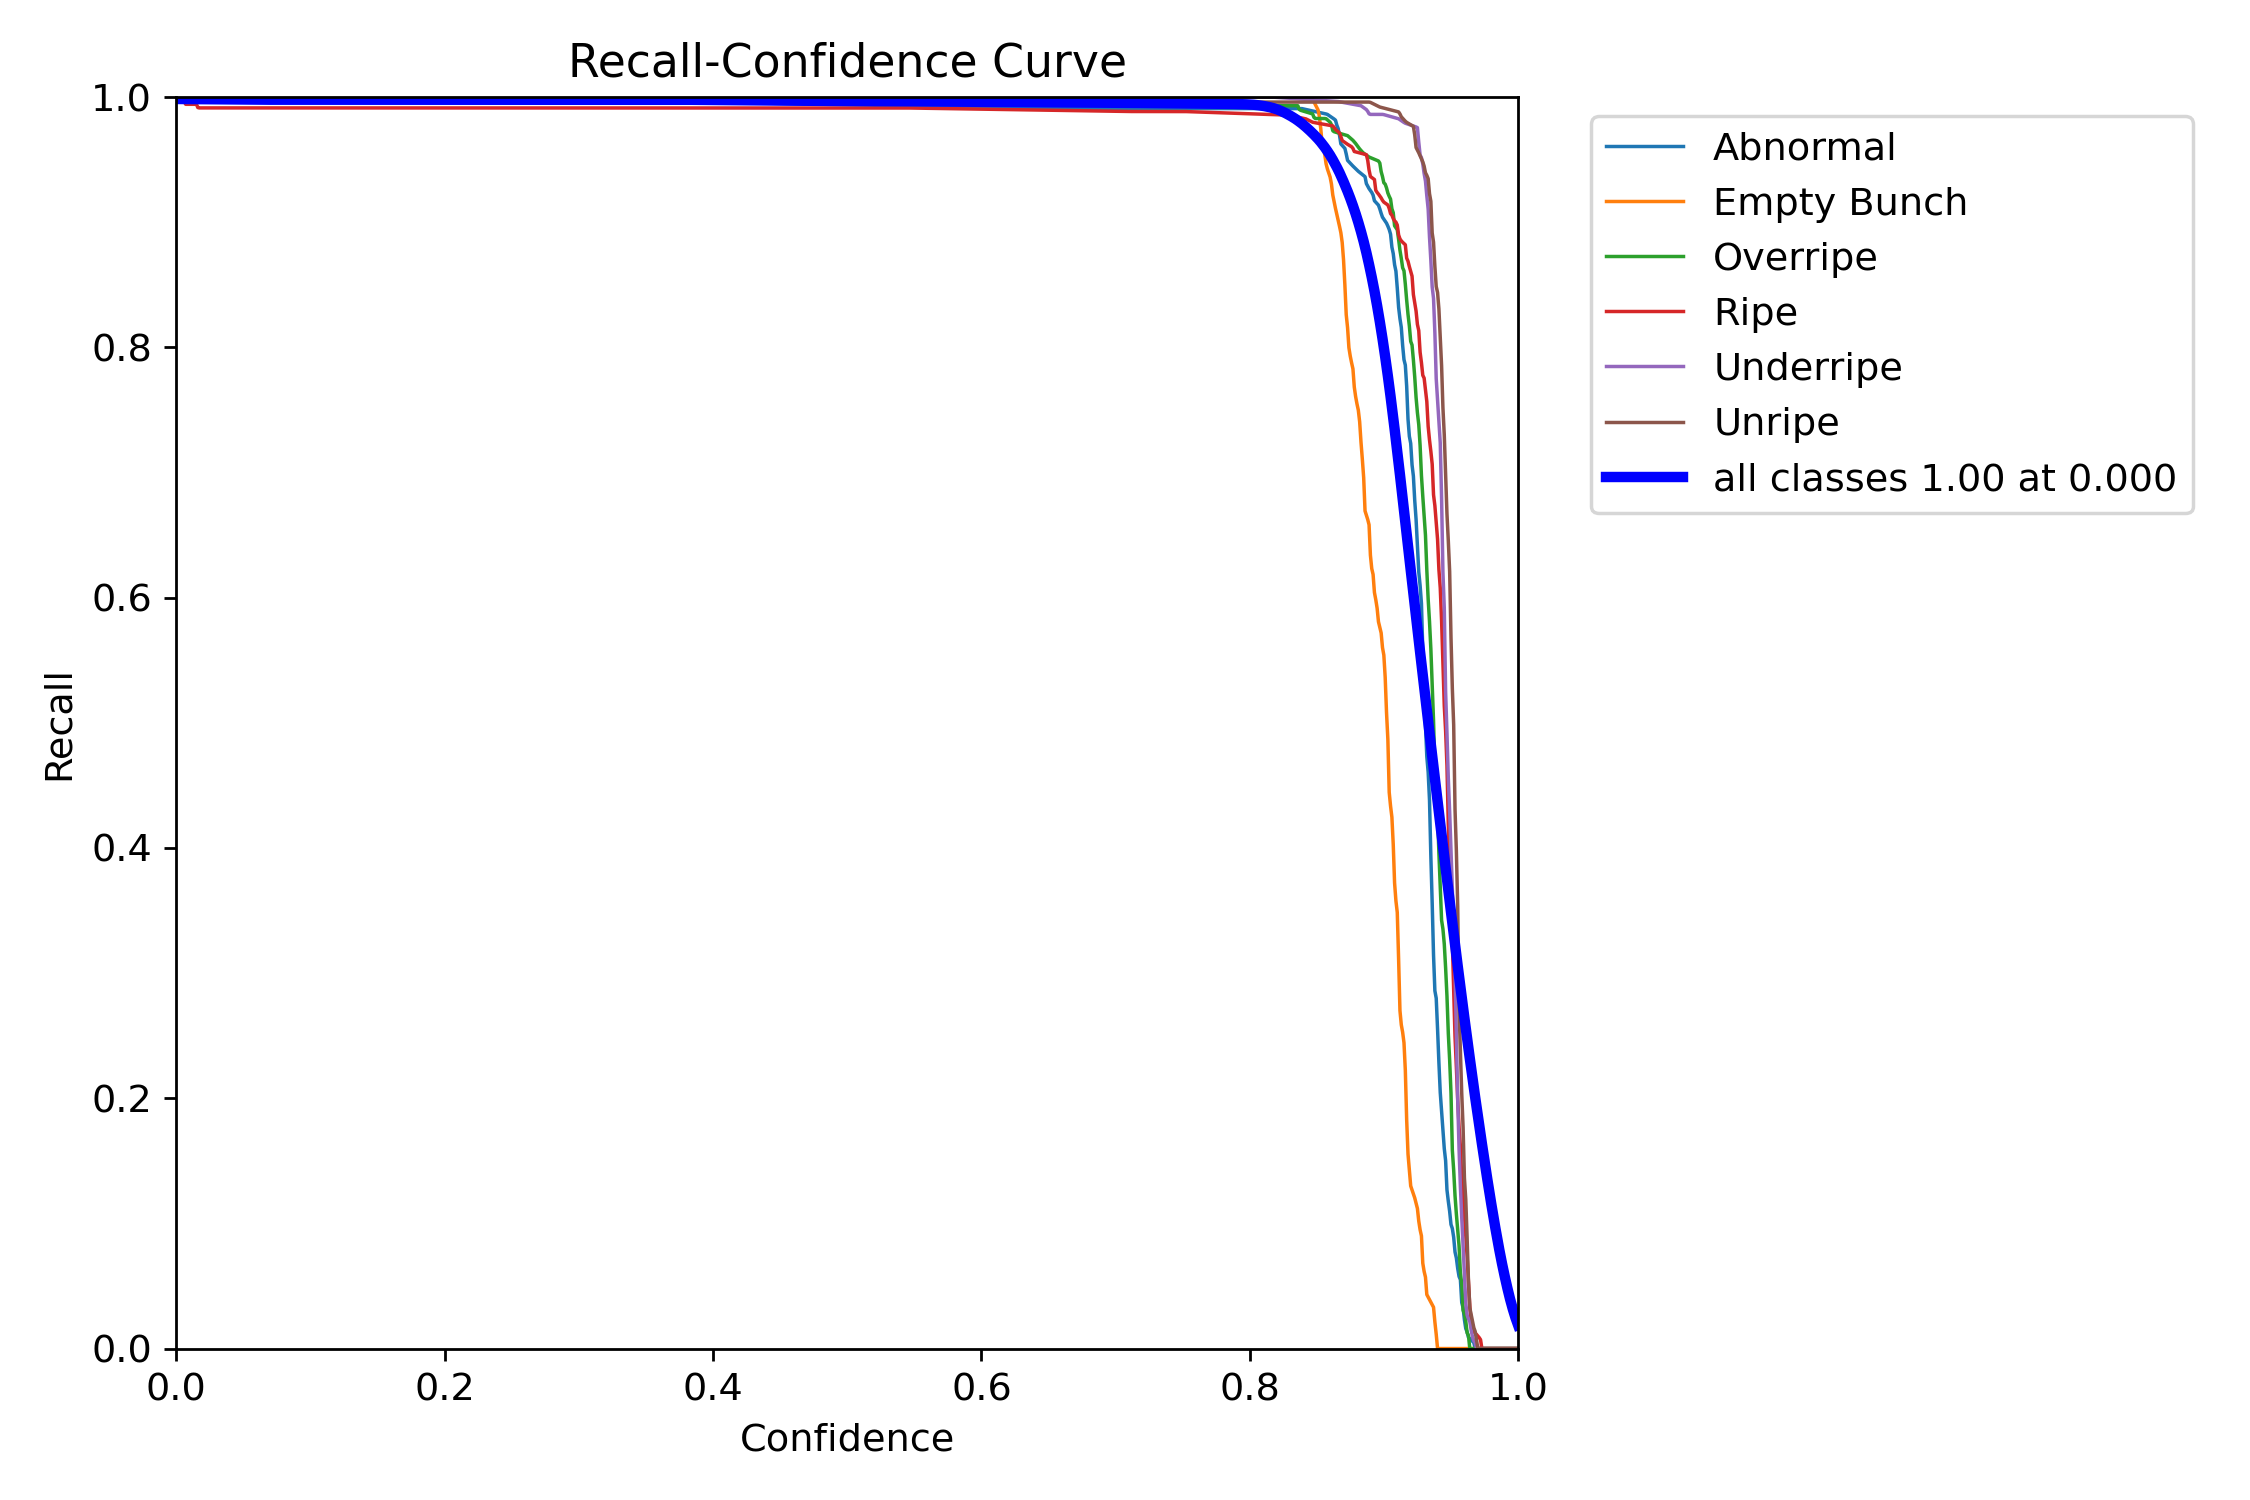

In [17]:
from IPython.display import Image, display
import os

eval_dir = f'{PROJECT_DIR}/{RUN_NAME}_eval'
for fname in [
    'confusion_matrix.png',
    'confusion_matrix_normalized.png',
    'BoxPR_curve.png',
    'BoxF1_curve.png',
    'BoxP_curve.png',
    'BoxR_curve.png',
]:
    fpath = os.path.join(eval_dir, fname)
    if os.path.exists(fpath):
        print(f'\n{fname}:')
        display(Image(fpath))
    else:
        print(f'\n[skip] not found: {fname}')

In [16]:
import os
eval_dir = f'{PROJECT_DIR}/{RUN_NAME}_eval'
print(f'Folder: {eval_dir}\n')
for f in sorted(os.listdir(eval_dir)):
    size = os.path.getsize(os.path.join(eval_dir, f))
    print(f'  {f}  ({size//1024} KB)')

Folder: /content/runs/centralized/palm_yolov11n_100ep_eval

  BoxF1_curve.png  (156 KB)
  BoxPR_curve.png  (113 KB)
  BoxP_curve.png  (106 KB)
  BoxR_curve.png  (157 KB)
  confusion_matrix.png  (158 KB)
  confusion_matrix_normalized.png  (165 KB)
  val_batch0_labels.jpg  (926 KB)
  val_batch0_pred.jpg  (933 KB)
  val_batch1_labels.jpg  (851 KB)
  val_batch1_pred.jpg  (857 KB)
  val_batch2_labels.jpg  (813 KB)
  val_batch2_pred.jpg  (819 KB)


## 7. Simpan Checkpoint ke Google Drive

Hasil training disimpan ke Drive sehingga bisa dipakai sebagai $w_0$ (bobot awal) saat tahap Federated Learning di notebook berikutnya.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import shutil
from pathlib import Path

drive_dir = Path('/content/drive/MyDrive/fedx-palm/centralized_baseline')
drive_dir.mkdir(parents=True, exist_ok=True)

# Copy best.pt + last.pt + summary.json
src_dir = Path(f'{PROJECT_DIR}/{RUN_NAME}')
for fname in ['weights/best.pt', 'weights/last.pt', 'summary.json', 'results.csv', 'args.yaml']:
    src = src_dir / fname
    if src.exists():
        dst = drive_dir / src.name
        shutil.copy2(src, dst)
        print(f'✓ {dst}')

# Copy eval plots
eval_src = Path(f'{PROJECT_DIR}/{RUN_NAME}_eval')
(drive_dir / 'eval_plots').mkdir(exist_ok=True)
for fname in ['confusion_matrix.png', 'confusion_matrix_normalized.png', 'PR_curve.png', 'F1_curve.png', 'P_curve.png', 'R_curve.png']:
    src = eval_src / fname
    if src.exists():
        shutil.copy2(src, drive_dir / 'eval_plots' / fname)
        print(f'✓ eval_plots/{fname}')

print(f'\nSemua artefak baseline tersimpan di: {drive_dir}')

✓ /content/drive/MyDrive/fedx-palm/centralized_baseline/best.pt
✓ /content/drive/MyDrive/fedx-palm/centralized_baseline/last.pt
✓ /content/drive/MyDrive/fedx-palm/centralized_baseline/summary.json
✓ /content/drive/MyDrive/fedx-palm/centralized_baseline/results.csv
✓ /content/drive/MyDrive/fedx-palm/centralized_baseline/args.yaml
✓ eval_plots/confusion_matrix.png
✓ eval_plots/confusion_matrix_normalized.png

Semua artefak baseline tersimpan di: /content/drive/MyDrive/fedx-palm/centralized_baseline


## 8. Selesai — Langkah Berikutnya

Setelah baseline centralized ini berhasil:

1. **Catat angka final** untuk Tabel 4.4 tesis: mAP@0.5, Precision, Recall, F1 (centralized)
2. **Simpan `best.pt`** — ini jadi $w_0$ untuk semua client di tahap FL
3. **Notebook berikutnya:** `fedx_palm_colab_client.ipynb` untuk simulasi FL 4 client + DP-SGD + Grad-CAM++
4. **Setup VPS** (saat Anda sudah punya) untuk jalankan FL server aggregator — lihat panduan di `README.md`

**Catatan:** Angka centralized di sini akan jadi *upper bound* performa. Federated learning dengan Non-IID + DP umumnya berada 1–3% di bawahnya pada baseline (ε=∞), dan turun lebih dalam saat ε mengecil.